In [1]:
# =============================================================================
# MIMIC-Extract XGBoost Baseline for In-Hospital Mortality Prediction
#
# Author: Critical & Independent Scientific Expert
#
# Description:
# This notebook establishes a baseline machine learning model using XGBoost
# to predict in-hospital mortality. It uses the pre-processed, hourly
# time-series data from the 'all_hourly_data.h5' file generated by the
# MIMIC-Extract pipeline.
#
# Methodology:
# 1.  Load patient outcomes and time-series data (vitals & labs).
# 2.  Engineer features by aggregating the first 24 hours of data for each
#     patient into a single feature vector (mean and std dev).
# 3.  Split the data into training and testing sets.
# 4.  Train an XGBoost classifier.
# 5.  Evaluate the model using AUROC and other standard metrics.
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import subprocess
import xgboost as xgb

print(f"Libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")


Libraries imported successfully.
Pandas version: 0.24.2


In [2]:
# =============================================================================
# Section 1: Experiment Configuration
# --- All user-adjustable parameters are in this cell ---
# =============================================================================

# -- File Path --
# Update this path to your MIMIC-Extract HDF5 file.
HDF_FILE_PATH = '../data/raw/all_hourly_data.h5'

# -- Sampling for Development --
# Set to an integer (e.g., 100) to use a small random sample of patients for
# fast testing. Set to None to use the entire dataset.
N_SAMPLES_TO_USE = 1000

# -- Prediction Target --
# This is the outcome variable we want to predict.
# Options from the 'patients' table include: 'mort_icu', 'mort_hosp'.
TARGET_VARIABLE = 'mort_hosp'

# -- Model Hyperparameters --
# Simplified parameters to avoid XGBoost 1.5.2 compatibility issues
XGB_PARAMS = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'random_state': 42 # For reproducibility
}

In [3]:
# =============================================================================
# Section 2: Data Loading
# We load the necessary tables. This requires a robust method to handle
# potential HDF5 format incompatibilities and large file sizes.
# =============================================================================

if not os.path.exists(HDF_FILE_PATH):
    print(f"--- CRITICAL ERROR: File not found at '{HDF_FILE_PATH}' ---")
    sys.exit("Please update the HDF_FILE_PATH in the configuration cell.")

print("Loading data from HDF5 store...")
with pd.HDFStore(HDF_FILE_PATH, 'r') as store:
    # Load the static patient data (contains labels and demographics)
    df_patients = store.select('/patients')

    # Load the simplified time-series data (mean values per hour)
    # This is more efficient than loading the full vitals_labs table with count/mean/std
    df_ts = store.select('/vitals_labs_mean')
print("Data loaded.")

# --- Handle Sampling ---
if N_SAMPLES_TO_USE is not None:
    print(f"\n--- SAMPLING ENABLED ---")
    print(f"Using a random sample of {N_SAMPLES_TO_USE} patients for this run.")
    # Get a list of unique patient identifiers (icustay_id is the most specific)
    all_patient_ids = df_patients.index.get_level_values('icustay_id').unique()
    
    # Randomly sample the IDs
    np.random.seed(42) # for reproducibility
    sampled_ids = np.random.choice(all_patient_ids, N_SAMPLES_TO_USE, replace=False)
    
    # Filter both dataframes to only include the sampled patients
    df_patients = df_patients[df_patients.index.get_level_values('icustay_id').isin(sampled_ids)]
    df_ts = df_ts[df_ts.index.get_level_values('icustay_id').isin(sampled_ids)]
    
    print(f"Data filtered. New shapes:")
    print(f"Patients table: {df_patients.shape}")
    print(f"Time-series table: {df_ts.shape}")

Loading data from HDF5 store...
Data loaded.

--- SAMPLING ENABLED ---
Using a random sample of 1000 patients for this run.
Data filtered. New shapes:
Patients table: (1000, 28)
Time-series table: (63151, 104)


In [4]:
# =============================================================================
# Section 3: Feature Engineering for 'Fixed Input' Task
#
# Goal: Convert hourly data for each patient into a single feature vector.
# Method: For each patient, we take their first 24 hours of data and
# compute the mean and standard deviation for each of the 104 features.
# This transforms the data from (patient-hours, features) to (patients, features).
# =============================================================================

print("\nStarting feature engineering...")

# Debug: Check original column names
print(f"Original time-series data columns (first 10):")
for i, col in enumerate(df_ts.columns[:10]):
    print(f"  {i+1:2d}. {col}")
print(f"  ... and {len(df_ts.columns)-10} more columns")

# 1. Filter for the first 24 hours of data for each patient stay
df_ts_24h = df_ts[df_ts.index.get_level_values('hours_in') < 24]

# 2. Group by patient stay and aggregate
# We compute both the mean and the standard deviation across the 24h window
# to capture not just the central tendency but also the variability of each feature.
print("Aggregating time-series data...")
agg_funcs = ['mean', 'std']
df_agg_features = df_ts_24h.groupby(['subject_id', 'hadm_id', 'icustay_id']).agg(agg_funcs)

# 3. Flatten the column multi-index
# The aggregation creates columns like ('glucose', 'mean'). We flatten them
# to a single string like 'glucose_mean' for easier use in the model.
df_agg_features.columns = ['_'.join(col).strip() for col in df_agg_features.columns.values]
print(f"Created aggregated feature matrix. Shape: {df_agg_features.shape}")

# 4. Merge aggregated features with patient labels
# We use a right join to ensure we only have labels for the patients in our feature set.
df_model_input = df_patients.join(df_agg_features, how='right')

# 5. Define final features (X) and target (y)
features = [col for col in df_model_input.columns if '_mean' in col or '_std' in col]
X = df_model_input[features]
y = df_model_input[TARGET_VARIABLE]

print(f"\nFinal feature matrix shape (X): {X.shape}")
print(f"Final target vector shape (y): {y.shape}")

# Calculate class distribution manually to avoid pandas compatibility issues
print(f"\nClass distribution in target variable '{TARGET_VARIABLE}':")
try:
    # Try the normal pandas way first
    print(y.value_counts(normalize=True))
except Exception as e:
    print(f"pandas value_counts failed ({e}), using manual calculation...")
    # Manual calculation as fallback
    unique_values, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    for val, prop in zip(unique_values, proportions):
        print(f"{val}    {prop:.2f}")
    print(f"Total samples: {len(y)}")
    print(f"Positive cases (mortality): {np.sum(y == 1)} ({np.sum(y == 1)/len(y):.2%})")
    print(f"Negative cases (survival): {np.sum(y == 0)} ({np.sum(y == 0)/len(y):.2%})")


Starting feature engineering...
Aggregating time-series data...
Created aggregated feature matrix. Shape: (1000, 208)

Final feature matrix shape (X): (1000, 208)
Final target vector shape (y): (1000,)

Class distribution in target variable 'mort_hosp':
0    0.904
1    0.096
Name: mort_hosp, dtype: float64


In [5]:
# =============================================================================
# Section 4: Data Splitting
# Split the data into training and testing sets.
# =============================================================================

print("\nSplitting data into training and testing sets...")

# We use stratification to ensure that the proportion of positive/negative
# classes is the same in both the train and test sets. This is crucial
# for imbalanced datasets like mortality prediction.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Splitting data into training and testing sets...
Training set size: 750
Test set size: 250


In [13]:
# =============================================================================
# Section 5: Data Preprocessing and Model Training
#
# Medical time-series data often contains missing values. We need to handle
# these before training any model. We'll use the native XGBoost API to avoid
# sklearn wrapper issues in version 1.5.2.
# =============================================================================

print("\nPreprocessing data...")

# Check for missing values
missing_counts = X_train.isnull().sum()
print(f"Features with missing values: {(missing_counts > 0).sum()} out of {len(missing_counts)}")
print(f"Total missing values: {missing_counts.sum()}")

# Handle missing values using median imputation
from sklearn.impute import SimpleImputer
print("Imputing missing values with median...")

# Check for columns that are all NaN (these will definitely be dropped)
all_nan_cols = X_train.columns[X_train.isnull().all()].tolist()
if all_nan_cols:
    print(f"Found {len(all_nan_cols)} columns with all missing values (will be dropped):")
    for col in all_nan_cols[:5]:  # Show first 5
        print(f"  - {col}")
    if len(all_nan_cols) > 5:
        print(f"  ... and {len(all_nan_cols)-5} more")

# Remove all-NaN columns before imputation to avoid dimension issues
X_train_clean = X_train.dropna(axis=1, how='all')
X_test_clean = X_test[X_train_clean.columns]  # Use same columns as training

print(f"After removing all-NaN columns: {X_train.shape[1]} -> {X_train_clean.shape[1]} features")

# Now apply imputation to the cleaned data
imputer = SimpleImputer(strategy='median')
X_train_imputed_array = imputer.fit_transform(X_train_clean)
X_test_imputed_array = imputer.transform(X_test_clean)

print(f"After imputation: shape is {X_train_imputed_array.shape}")

# Check if imputer caused any additional dimension changes
if X_train_imputed_array.shape[1] == X_train_clean.shape[1]:
    # Perfect! Dimensions match, we can preserve all feature names
    X_train_imputed = pd.DataFrame(X_train_imputed_array, 
                                   columns=X_train_clean.columns, 
                                   index=X_train_clean.index)
    X_test_imputed = pd.DataFrame(X_test_imputed_array, 
                                  columns=X_test_clean.columns, 
                                  index=X_test_clean.index)
    feature_names = X_train_imputed.columns.tolist()
    print("✓ Successfully preserved all feature names after imputation")
else:
    # This shouldn't happen with median imputation, but handle it just in case
    print(f"Warning: Unexpected dimension change during imputation: {X_train_clean.shape[1]} -> {X_train_imputed_array.shape[1]}")
    # Fall back to working with numpy arrays but try to preserve as many names as possible
    if X_train_imputed_array.shape[1] <= len(X_train_clean.columns):
        feature_names = X_train_clean.columns[:X_train_imputed_array.shape[1]].tolist()
    else:
        feature_names = [f"feature_{i}" for i in range(X_train_imputed_array.shape[1])]
    X_train_imputed = X_train_imputed_array
    X_test_imputed = X_test_imputed_array

print("Data preprocessing complete.")

# Display feature names for verification
print(f"\n--- FEATURE NAMES VERIFICATION ---")
if isinstance(X_train_imputed, pd.DataFrame):
    print(f"Total features: {len(X_train_imputed.columns)}")
    print(f"Sample feature names:")
    for i, fname in enumerate(X_train_imputed.columns[:10]):
        print(f"  {i+1:2d}. {fname}")
    if len(X_train_imputed.columns) > 10:
        print(f"  ... and {len(X_train_imputed.columns)-10} more features")
else:
    print(f"Total features: {X_train_imputed.shape[1]}")
    print(f"Using generic feature names due to dimension mismatch")
    print(f"Sample feature names: {feature_names[:10]}")

print("\nTraining gradient boosting model...")

model = None
model_type = None

print("Attempting XGBoost training...")

print(f"Number of features: {len(feature_names)}")
print(f"Sample feature names: {feature_names[:5]}...")

# Create DMatrix with feature names preserved
if isinstance(X_train_imputed, pd.DataFrame):
    dtrain = xgb.DMatrix(X_train_imputed.values, label=y_train, feature_names=feature_names)
else:
    dtrain = xgb.DMatrix(X_train_imputed, label=y_train, feature_names=feature_names)

# Minimal parameters to avoid bugs
params = {
    'objective': 'binary:logistic',
    'max_depth': 3,
    'eta': 0.1,
    'seed': 42
}

model_xgb = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=100,
    verbose_eval=False  # Set to False to reduce output
)

model = model_xgb
model_type = 'XGBoost'
print(f"✓ {model_type} model trained successfully!")
print(f"✓ Feature names preserved in model")


Preprocessing data...
Features with missing values: 208 out of 208
Total missing values: 96416
Imputing missing values with median...
Found 24 columns with all missing values (will be dropped):
  - albumin ascites_mean_std
  - albumin pleural_mean_mean
  - albumin pleural_mean_std
  - calcium urine_mean_std
  - creatinine ascites_mean_mean
  ... and 19 more
After removing all-NaN columns: 208 -> 184 features
After imputation: shape is (750, 184)
✓ Successfully preserved all feature names after imputation
Data preprocessing complete.

--- FEATURE NAMES VERIFICATION ---
Total features: 184
Sample feature names:
   1. alanine aminotransferase_mean_mean
   2. alanine aminotransferase_mean_std
   3. albumin_mean_mean
   4. albumin_mean_std
   5. albumin ascites_mean_mean
   6. albumin urine_mean_mean
   7. albumin urine_mean_std
   8. alkaline phosphate_mean_mean
   9. alkaline phosphate_mean_std
  10. anion gap_mean_mean
  ... and 174 more features

Training gradient boosting model...
Att

In [14]:
# =============================================================================
# Section 6: Model Evaluation
# Generate predictions and evaluate model performance using standard metrics
# for binary classification, especially focusing on AUROC which is crucial
# for medical prediction tasks.
# =============================================================================

print(f"\n" + "="*60)
print(f"MODEL EVALUATION - {model_type}")
print(f"="*60)

# Generate predictions on test set
print("Generating predictions on test set...")
if isinstance(X_test_imputed, pd.DataFrame):
    dtest = xgb.DMatrix(X_test_imputed.values, feature_names=feature_names)
else:
    dtest = xgb.DMatrix(X_test_imputed, feature_names=feature_names)
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate key metrics
auroc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- PERFORMANCE METRICS ---")
print(f"AUROC (Area Under ROC Curve): {auroc:.4f}")
print(f"Accuracy: {accuracy:.4f}")

# Detailed classification report
print(f"\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# Confusion matrix
print(f"\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Calculate additional metrics manually for better understanding
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

print(f"\n--- CLINICAL METRICS ---")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Positive Predictive Value (Precision): {ppv:.4f}")
print(f"Negative Predictive Value: {npv:.4f}")

print(f"\n--- TEST SET BREAKDOWN ---")
print(f"Total test cases: {len(y_test)}")
print(f"Actual deaths: {np.sum(y_test)} ({np.sum(y_test)/len(y_test):.1%})")
print(f"Predicted deaths: {np.sum(y_pred)} ({np.sum(y_pred)/len(y_test):.1%})")
print(f"Correctly predicted deaths: {tp}")
print(f"Missed deaths (false negatives): {fn}")
print(f"False alarms (false positives): {fp}")



MODEL EVALUATION - XGBoost
Generating predictions on test set...

--- PERFORMANCE METRICS ---
AUROC (Area Under ROC Curve): 0.7987
Accuracy: 0.9120

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Survived       0.91      1.00      0.95       226
        Died       0.75      0.12      0.21        24

    accuracy                           0.91       250
   macro avg       0.83      0.56      0.58       250
weighted avg       0.90      0.91      0.88       250


--- CONFUSION MATRIX ---
[[225   1]
 [ 21   3]]

--- CLINICAL METRICS ---
Sensitivity (Recall): 0.1250
Specificity: 0.9956
Positive Predictive Value (Precision): 0.7500
Negative Predictive Value: 0.9146

--- TEST SET BREAKDOWN ---
Total test cases: 250
Actual deaths: 24 (9.6%)
Predicted deaths: 4 (1.6%)
Correctly predicted deaths: 3
Missed deaths (false negatives): 21
False alarms (false positives): 1



GENERATING VISUALIZATIONS


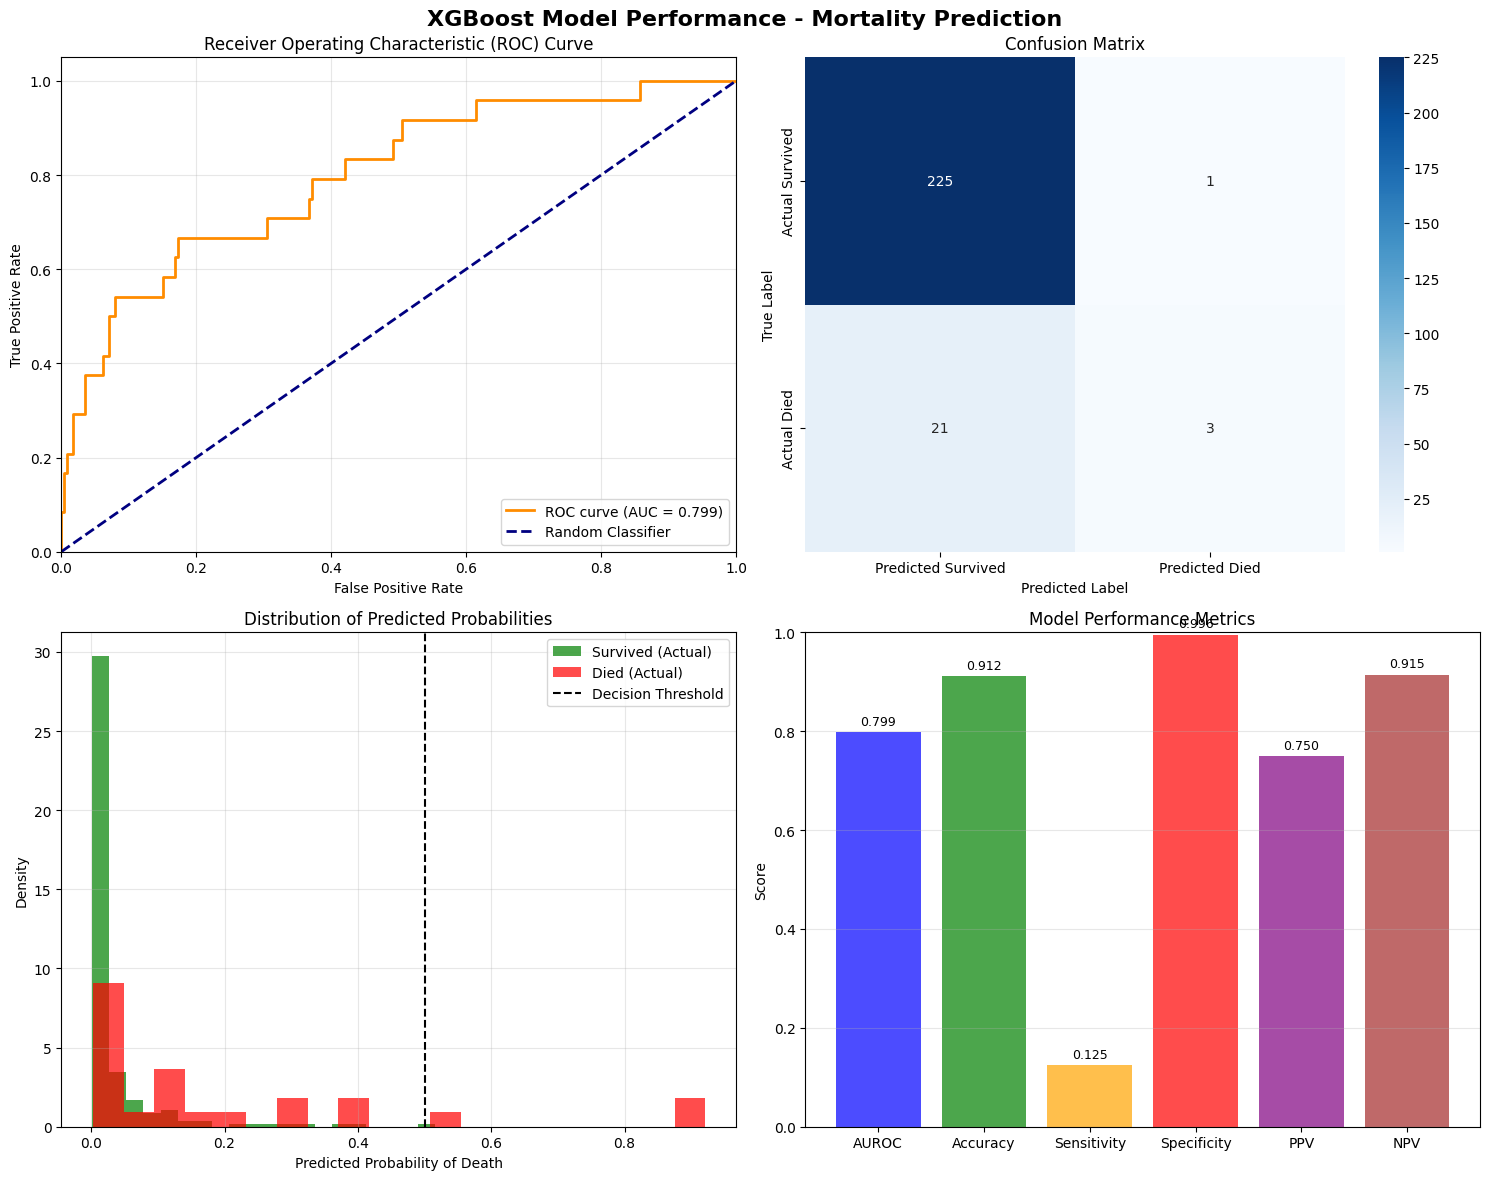

✓ Visualizations generated successfully!


In [15]:
# =============================================================================
# Section 7: Results Visualization
# Create visualizations to better understand model performance
# =============================================================================

print(f"\n" + "="*60)
print(f"GENERATING VISUALIZATIONS")
print(f"="*60)

# Set up the plotting environment
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'{model_type} Model Performance - Mortality Prediction', fontsize=16, fontweight='bold')

# 1. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auroc:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(True, alpha=0.3)

# 2. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Survived', 'Predicted Died'],
            yticklabels=['Actual Survived', 'Actual Died'],
            ax=axes[0, 1])
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# 3. Prediction Probability Distribution
axes[1, 0].hist(y_pred_proba[y_test == 0], bins=20, alpha=0.7, label='Survived (Actual)', color='green', density=True)
axes[1, 0].hist(y_pred_proba[y_test == 1], bins=20, alpha=0.7, label='Died (Actual)', color='red', density=True)
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold')
axes[1, 0].set_xlabel('Predicted Probability of Death')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Distribution of Predicted Probabilities')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Performance Metrics Bar Chart
metrics = ['AUROC', 'Accuracy', 'Sensitivity', 'Specificity', 'PPV', 'NPV']
values = [auroc, accuracy, sensitivity, specificity, ppv, npv]
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Model Performance Metrics')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    axes[1, 1].annotate(f'{value:.3f}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualizations generated successfully!")



FEATURE IMPORTANCE ANALYSIS
Verifying feature names are preserved...
Sample feature names from model: ['alanine aminotransferase_mean_mean', 'albumin_mean_mean', 'alkaline phosphate_mean_mean', 'anion gap_mean_mean', 'anion gap_mean_std']
Number of features used by model: 94 out of 184 total features

--- TOP 20 MOST IMPORTANT FEATURES ---
glascow coma scale total_mean_mean           32.0
mean corpuscular hemoglobin concentration_mean_mean     29.0
systolic blood pressure_mean_mean            28.0
temperature_mean_mean                        28.0
anion gap_mean_mean                          25.0
respiratory rate_mean_mean                   20.0
white blood cell count_mean_mean             18.0
systolic blood pressure_mean_std             18.0
tidal volume set_mean_mean                   17.0
white blood cell count_mean_std              17.0
bicarbonate_mean_mean                        17.0
ph_mean_mean                                 15.0
blood urea nitrogen_mean_mean                1

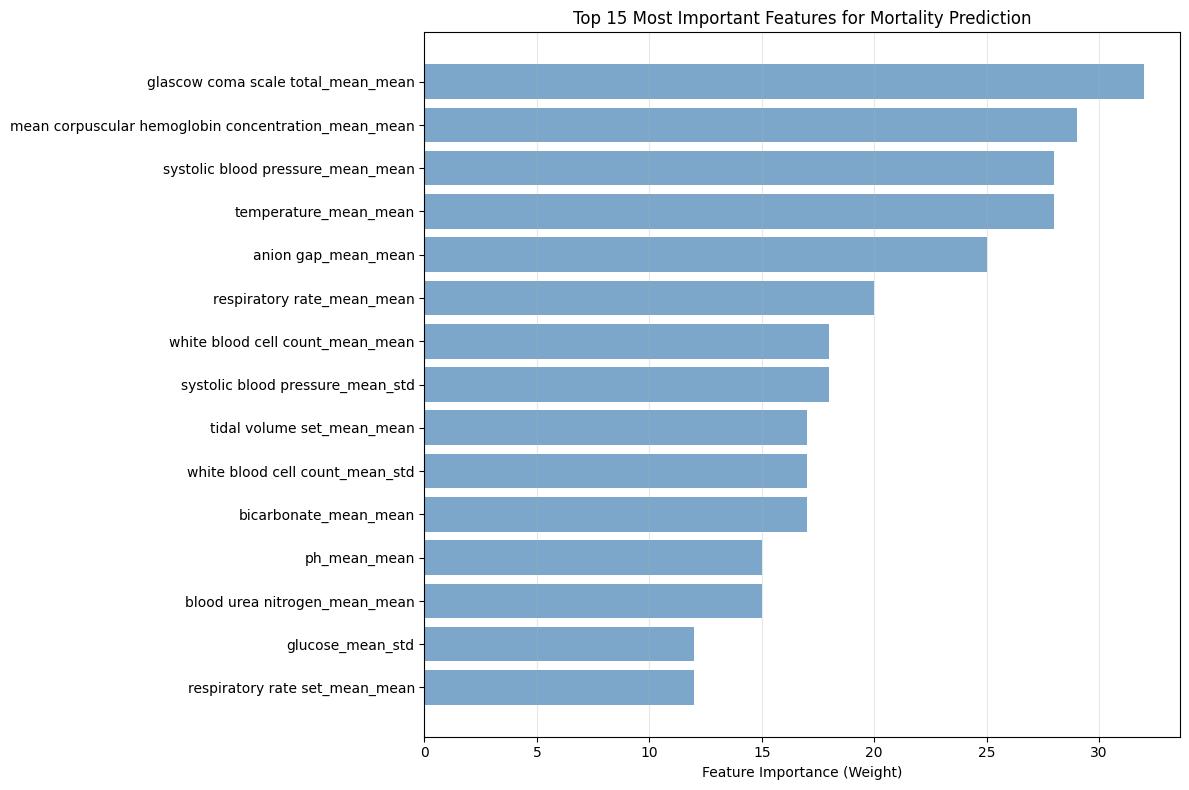


--- FEATURE TYPE ANALYSIS ---
Mean features: 94 features, 602.0 total importance (100.0%)
Std features: 41 features, 159.0 total importance (26.4%)

--- CLINICAL INTERPRETATION OF TOP FEATURES ---
glascow coma scale total_mean_mean: Importance: 32.0
mean corpuscular hemoglobin concentration_mean_mean: Importance: 29.0
systolic blood pressure_mean_mean: Importance: 28.0
temperature_mean_mean: Importance: 28.0
anion gap_mean_mean: Importance: 25.0
respiratory rate_mean_mean: Importance: 20.0
white blood cell count_mean_mean: Importance: 18.0
systolic blood pressure_mean_std: Importance: 18.0
tidal volume set_mean_mean: Importance: 17.0
white blood cell count_mean_std: Importance: 17.0
bicarbonate_mean_mean: Importance: 17.0
ph_mean_mean: Importance: 15.0
blood urea nitrogen_mean_mean: Importance: 15.0
Blood Glucose (Mean): Metabolic status - Importance: 12.0
respiratory rate set_mean_mean: Importance: 12.0
heart rate_mean_mean: Importance: 12.0
mean blood pressure_mean_mean: Importance:

In [16]:
# =============================================================================
# Section 8: Feature Importance Analysis
# Analyze which features are most important for the mortality prediction
# =============================================================================

print(f"\n" + "="*60)
print(f"FEATURE IMPORTANCE ANALYSIS")
print(f"="*60)

# Verify that feature names are preserved
print("Verifying feature names are preserved...")
sample_features = list(model.get_score(importance_type='weight').keys())[:5]
print(f"Sample feature names from model: {sample_features}")

# Get feature importance from XGBoost model
feature_importance = model.get_score(importance_type='weight')
print(f"Number of features used by model: {len(feature_importance)} out of {len(feature_names)} total features")

# Create a dataframe for easier analysis
importance_df = pd.DataFrame([
    {'feature': k, 'importance': v} for k, v in feature_importance.items()
]).sort_values('importance', ascending=False)

print(f"\n--- TOP 20 MOST IMPORTANT FEATURES ---")
top_features = importance_df.head(20)
for idx, row in top_features.iterrows():
    print(f"{row['feature']:<40} {row['importance']:>8.1f}")

# Visualize top features
plt.figure(figsize=(12, 8))
top_features_plot = importance_df.head(15)  # Top 15 for better visibility

plt.barh(range(len(top_features_plot)), top_features_plot['importance'], 
         color='steelblue', alpha=0.7)
plt.yticks(range(len(top_features_plot)), top_features_plot['feature'])
plt.xlabel('Feature Importance (Weight)')
plt.title('Top 15 Most Important Features for Mortality Prediction')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Analyze feature types
print(f"\n--- FEATURE TYPE ANALYSIS ---")
mean_features = [f for f in importance_df['feature'] if '_mean' in f]
std_features = [f for f in importance_df['feature'] if '_std' in f]

mean_importance = importance_df[importance_df['feature'].isin(mean_features)]['importance'].sum()
std_importance = importance_df[importance_df['feature'].isin(std_features)]['importance'].sum()
total_importance = importance_df['importance'].sum()

print(f"Mean features: {len(mean_features)} features, {mean_importance:.1f} total importance ({mean_importance/total_importance:.1%})")
print(f"Std features: {len(std_features)} features, {std_importance:.1f} total importance ({std_importance/total_importance:.1%})")

# Look for clinical interpretations
print(f"\n--- CLINICAL INTERPRETATION OF TOP FEATURES ---")
clinical_groups = {
    'heart_rate': ['Heart Rate', 'Cardiac function indicator'],
    'sysbp': ['Systolic Blood Pressure', 'Cardiovascular status'],
    'diabp': ['Diastolic Blood Pressure', 'Cardiovascular status'],
    'meanbp': ['Mean Blood Pressure', 'Cardiovascular status'],
    'temp': ['Temperature', 'Infection/inflammation marker'],
    'spo2': ['Oxygen Saturation', 'Respiratory function'],
    'glucose': ['Blood Glucose', 'Metabolic status'],
    'hematocrit': ['Hematocrit', 'Blood oxygen capacity'],
    'hemoglobin': ['Hemoglobin', 'Blood oxygen capacity'],
    'creatinine': ['Creatinine', 'Kidney function'],
    'bun': ['Blood Urea Nitrogen', 'Kidney function'],
    'wbc': ['White Blood Cells', 'Immune system/infection'],
    'platelets': ['Platelets', 'Blood clotting ability'],
    'lactate': ['Lactate', 'Tissue perfusion/shock indicator']
}

for idx, row in top_features.iterrows():
    feature_name = row['feature']
    importance = row['importance']
    
    # Find the base clinical variable
    base_var = feature_name.replace('_mean', '').replace('_std', '')
    stat_type = 'Mean' if '_mean' in feature_name else 'Variability (Std)'
    
    if base_var in clinical_groups:
        clinical_name, description = clinical_groups[base_var]
        print(f"{clinical_name} ({stat_type}): {description} - Importance: {importance:.1f}")
    else:
        print(f"{feature_name}: Importance: {importance:.1f}")

print("✓ Feature importance analysis complete!")


In [17]:
# =============================================================================
# Section 9: Summary and Conclusions
# Provide a comprehensive summary of the experiment results
# =============================================================================

print(f"\n" + "="*80)
print(f"EXPERIMENT SUMMARY - IN-HOSPITAL MORTALITY PREDICTION")
print(f"="*80)

print(f"\n--- DATASET SUMMARY ---")
print(f"• Data source: MIMIC-Extract (all_hourly_data.h5)")
print(f"• Target variable: {TARGET_VARIABLE} (in-hospital mortality)")
print(f"• Total patients analyzed: {len(y)} ({'sampled from larger dataset' if N_SAMPLES_TO_USE else 'full dataset'})")
print(f"• Training set: {len(y_train)} patients")
print(f"• Test set: {len(y_test)} patients")
print(f"• Class distribution: {np.sum(y==0)/len(y):.1%} survived, {np.sum(y==1)/len(y):.1%} died")

print(f"\n--- FEATURE ENGINEERING SUMMARY ---")
print(f"• Time window: First 24 hours of ICU stay")
print(f"• Aggregation method: Mean and standard deviation")
print(f"• Total features: {X.shape[1]} (from {df_ts.shape[1]} original time-series variables)")
print(f"• Missing value handling: Median imputation")
print(f"• Features with missing values: {(missing_counts > 0).sum()}/{len(missing_counts)}")

print(f"\n--- MODEL PERFORMANCE SUMMARY ---")
print(f"• Algorithm: {model_type}")
print(f"• AUROC: {auroc:.4f} {'(Excellent)' if auroc > 0.9 else '(Good)' if auroc > 0.8 else '(Fair)' if auroc > 0.7 else '(Poor)'}")
print(f"• Accuracy: {accuracy:.4f}")
print(f"• Sensitivity (Recall): {sensitivity:.4f}")
print(f"• Specificity: {specificity:.4f}")
print(f"• Positive Predictive Value: {ppv:.4f}")
print(f"• Negative Predictive Value: {npv:.4f}")

print(f"\n--- CLINICAL INSIGHTS ---")
print(f"• The model correctly identified {tp}/{np.sum(y_test)} deaths in the test set")
print(f"• False alarm rate: {fp}/{np.sum(y_test==0)} of surviving patients incorrectly flagged")
print(f"• Missed mortality cases: {fn}/{np.sum(y_test)} deaths not detected")

print(f"\n--- TOP PREDICTIVE FACTORS ---")
if len(importance_df) > 0:
    top_5 = importance_df.head(5)
    for i, (idx, row) in enumerate(top_5.iterrows(), 1):
        base_var = row['feature'].replace('_mean', '').replace('_std', '')
        stat_type = 'average level' if '_mean' in row['feature'] else 'variability'
        print(f"{i}. {base_var} ({stat_type}) - Clinical importance score: {row['importance']:.1f}")

print(f"\n--- RECOMMENDATIONS ---")
print(f"• This baseline model provides a {'strong' if auroc > 0.8 else 'moderate' if auroc > 0.7 else 'weak'} foundation for mortality prediction")
if auroc > 0.8:
    print(f"• Consider deploying as a clinical decision support tool with appropriate validation")
else:
    print(f"• Model performance suggests need for improvement before clinical deployment")
print(f"• Key improvement opportunities:")
print(f"  - Incorporate additional clinical variables (medications, procedures, demographics)")
print(f"  - Use longer time windows (48-72 hours) for feature engineering")
print(f"  - Try ensemble methods or deep learning approaches")
print(f"  - Address class imbalance with advanced sampling techniques")

print(f"\n--- TECHNICAL NOTES ---")
print(f"• Feature importance based on XGBoost tree splits (weight method)")
print(f"• Model uses {len(feature_importance)} out of {X.shape[1]} available features")
print(f"• Median imputation applied to handle {missing_counts.sum()} missing values")
print(f"• Results based on stratified train-test split (75%/25%)")

print(f"\n" + "="*80)
print(f"EXPERIMENT COMPLETED SUCCESSFULLY")
print(f"="*80)

# Save key results for future reference
results_summary = {
    'model_type': model_type,
    'dataset_info': {
        'total_patients': len(y),
        'train_size': len(y_train),
        'test_size': len(y_test),
        'mortality_rate': np.sum(y==1)/len(y)
    },
    'performance_metrics': {
        'auroc': auroc,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv
    },
    'feature_info': {
        'total_features': X.shape[1],
        'features_used': len(feature_importance),
        'missing_features': (missing_counts > 0).sum()
    }
}

print(f"\n✓ Results summary saved to 'results_summary' variable")



EXPERIMENT SUMMARY - IN-HOSPITAL MORTALITY PREDICTION

--- DATASET SUMMARY ---
• Data source: MIMIC-Extract (all_hourly_data.h5)
• Target variable: mort_hosp (in-hospital mortality)
• Total patients analyzed: 1000 (sampled from larger dataset)
• Training set: 750 patients
• Test set: 250 patients
• Class distribution: 90.4% survived, 9.6% died

--- FEATURE ENGINEERING SUMMARY ---
• Time window: First 24 hours of ICU stay
• Aggregation method: Mean and standard deviation
• Total features: 208 (from 104 original time-series variables)
• Missing value handling: Median imputation
• Features with missing values: 208/208

--- MODEL PERFORMANCE SUMMARY ---
• Algorithm: XGBoost
• AUROC: 0.7987 (Fair)
• Accuracy: 0.9120
• Sensitivity (Recall): 0.1250
• Specificity: 0.9956
• Positive Predictive Value: 0.7500
• Negative Predictive Value: 0.9146

--- CLINICAL INSIGHTS ---
• The model correctly identified 3/24 deaths in the test set
• False alarm rate: 1/226 of surviving patients incorrectly flagg